In [2539]:
import time
import serial.tools.list_ports
ports = serial.tools.list_ports.comports()

for port, desc, hwid in sorted(ports):
    print("{}: {} [{}]".format(port, desc, hwid))

MyPort = 'COM11'
ser = serial.Serial(port=MyPort, baudrate=115200)

if ser.isOpen():
    print(ser.name + ' is open')
# time.sleep(1) # seconds

COM11: Silicon Labs CP210x USB to UART Bridge (COM11) [USB VID:PID=10C4:EA60 SER=0001 LOCATION=1-3]
COM12: com0com - serial port emulator (COM12) [COM0COM\PORT\CNCB0]
COM13: Standard Serial over Bluetooth link (COM13) [BTHENUM\{00001101-0000-1000-8000-00805F9B34FB}_LOCALMFG&0002\7&BD9C83&1&98D332106D17_C00000000]
COM14: Standard Serial over Bluetooth link (COM14) [BTHENUM\{00001101-0000-1000-8000-00805F9B34FB}_LOCALMFG&0000\7&BD9C83&1&000000000000_00000000]
COM11 is open


Done. 180 samples received.


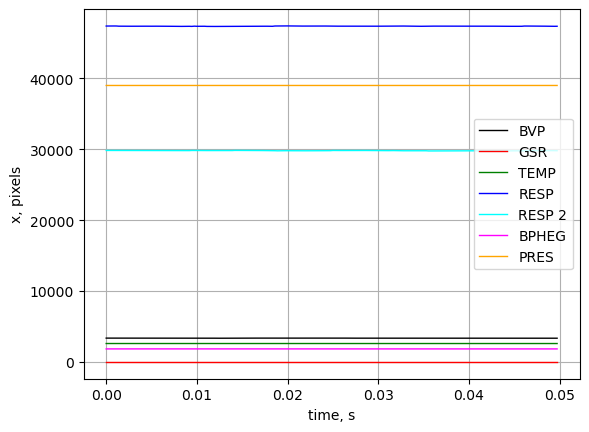

In [2638]:
KiekLaikoMatuoti = 3 # sekundemis
fs = 60 # sampling rate apie 60/s
DataLen = KiekLaikoMatuoti * fs # samples to receive from polygraph [16.8s 16.8s 16.7s]
# p1=[]
BVP=[]   # BVP  - Blood Volume Pulse - pulse fluctuations of blood volume signal from PPG sensor
GSR=[]   # GSR  - a signal from the galvanic skin response sensor
TEMP=[]  # TEMP - the signal from the temperature sensor
RESP=[]  # RESP - signal from the breathing sensor
RESP2=[] # RESP 2 - a signal from the second breathing sensor
BPHEG=[] # BPHEG - dynamic changes in blood pressure, the signal from the PPG sensor
PRES=[]  # PRESSURE - tremor sensor signal (the seat air pillow)
Time=[]
ser.flushInput(); ser.flushOutput(); i=0
while(True):
    D = ser.read(40) # duomenu paketas = 40 Baitu
    if (D[0]!=66 and D[1]!=70 and D[2]!=65 and D[3]!=249): # Check preamble 'BFA?' = 66 70 65 249
        ser.flushInput()
        ser.flushOutput()
#         print('Flushed')
    else: # jei teisingai prieme vektoriu, tai dekoduok rezultatus
#         p1.append(D[7]*256+D[6]) # parametras ???
        BVP.append(D[9]*256+D[8])
        GSR.append(D[11]*256+D[10])
        TEMP.append(D[13]*256+D[12])
        RESP.append(D[15]*256+D[14])
        RESP2.append(D[17]*256+D[16])
        BPHEG.append(D[19]*256+D[18])
        PRES.append(D[21]*256+D[20])
        Time.append(i)
        i=i+1
        if i==DataLen:
            break   
print('Done.',i,'samples received.') # print('p1',p1)
Data = []; Data.append(BVP); Data.append(GSR); Data.append(TEMP); 
Data.append(RESP); Data.append(RESP2); Data.append(BPHEG); Data.append(PRES);
# print('BVP',BVP)
# print('GSR',GSR)
# print('TEMP',TEMP)
# print('RESP',RESP)
# print('RESP2',RESP2)
# print('BPHEG',BPHEG)
# print('PRES',PRES)
Time = np.array(Time) / fs
plot(Data,Time)

In [2634]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline
legenddata = ['BVP','GSR','TEMP','RESP','RESP 2','BPHEG','PRES']
kpcolor=['black','red','green','blue','cyan','magenta','orange'] # ['black','red','green','blue','cyan','magenta','yellow','lime','orange','purple','pink','gray','olive','brown','violet']
style=['-','-','-','-','-','-','-']; linewidth=1;

def plot(Data,t):
    for i in range(len(Data)):
        x=np.array(Data[i][:]);
        plt.plot(t, x, style[i], color=kpcolor[i], linewidth=linewidth)
    plt.xlabel('time, s'); plt.ylabel('x, pixels'); #plt.gca().invert_yaxis()
    plt.legend(legenddata, loc='best'); # upper left,upper right,lower left,lower right | upper center,lower center,center left,center right
    plt.grid(); plt.show()


In [2655]:
np.savetxt('polygraph_data.csv', (BVP, GSR, TEMP, RESP, RESP2, BPHEG, PRES), delimiter=',', fmt='%1.0f')

In [2617]:
# i=0
# ch = D[0]
# for i in range(len(D)):
#     print(i,":", D[i])

In [2537]:
ser.close()